# Exercise 3

# Binary Image Cleaning Using Morphological Operations

This notebook demonstrates morphological operations for cleaning noisy
binary images. The exercise is implemented in two stages:

1. **Baseline implementation**, strictly following the exercise instructions.
2. **Extended analysis**, exploring kernel size, shape, operation order,
   and quantitative evaluation.

Morphological operations process image structures rather than individual
pixel values, making them particularly effective for binary image cleaning.


In [1]:
"""
Import required libraries for morphological image processing.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt


## Part 1: Baseline Morphological Cleaning (Required Task)

This section implements the exact steps specified in the exercise:

1. Load a color image and convert it to grayscale.
2. Convert the grayscale image to a binary image using thresholding.
3. Define a suitable structuring element (3×3 or 5×5).
4. Apply morphological opening to remove small white noise.
5. Apply morphological closing to fill small black holes.
6. Display the noisy binary image and the cleaned result.


In [2]:
"""
Load an image and convert it to grayscale.
"""

# Path to input image
image_path = "images/Lenna.png"

# Load color image
color_image = cv2.imread(image_path)

if color_image is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# Convert to grayscale
gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)


In [3]:
"""
Convert grayscale image to binary using global thresholding.
"""

# Apply binary thresholding
_, binary_noisy = cv2.threshold(
    gray_image,
    thresh=128,
    maxval=255,
    type=cv2.THRESH_BINARY
)


In [4]:
"""
Define the structuring element for morphological operations.
"""

# Define a rectangular structuring element (3x3)
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (3, 3)
)


In [5]:
"""
Apply morphological opening followed by closing.
"""

# Remove small white noise (salt noise)
opened_image = cv2.morphologyEx(
    binary_noisy,
    cv2.MORPH_OPEN,
    kernel
)

# Fill small black holes (pepper noise)
cleaned_image = cv2.morphologyEx(
    opened_image,
    cv2.MORPH_CLOSE,
    kernel
)


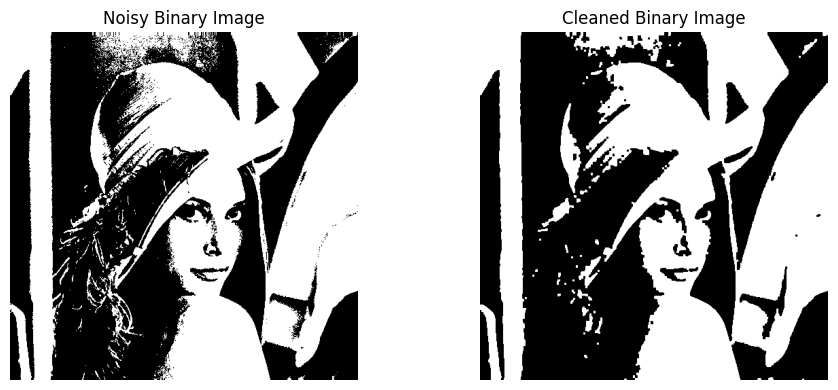

In [6]:
"""
Display noisy binary image and cleaned image.
"""

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Noisy Binary Image")
plt.imshow(binary_noisy, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Cleaned Binary Image")
plt.imshow(cleaned_image, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


### Discussion (Baseline)

Morphological opening successfully removes small isolated foreground
pixels, while closing fills small holes within objects.
The combined operation results in a cleaner binary image with improved
structural consistency.

This baseline implementation follows the exercise requirements and
serves as a reference for further morphological analysis.


## Part 2: Effect of Structuring Element Size

The size of the structuring element plays a critical role in morphological
operations. Larger kernels remove stronger noise but may distort fine
structures.


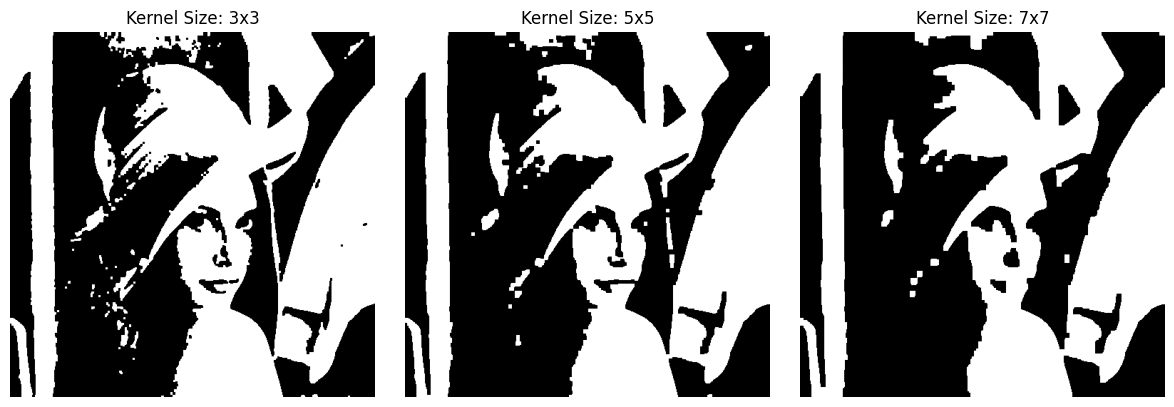

In [7]:
"""
Compare morphological cleaning using different kernel sizes.
"""

kernel_sizes = [3, 5, 7]

plt.figure(figsize=(12, 4))

for i, k in enumerate(kernel_sizes):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    opened = cv2.morphologyEx(binary_noisy, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    plt.subplot(1, 3, i + 1)
    plt.title(f"Kernel Size: {k}x{k}")
    plt.imshow(cleaned, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Discussion

As kernel size increases, noise removal becomes more aggressive.
However, excessive kernel sizes may eliminate thin structures or
distort object boundaries, highlighting a trade-off between cleaning
strength and shape preservation.


## Part 3: Effect of Structuring Element Shape

Different structuring element shapes influence how object geometry
is preserved during morphological processing.


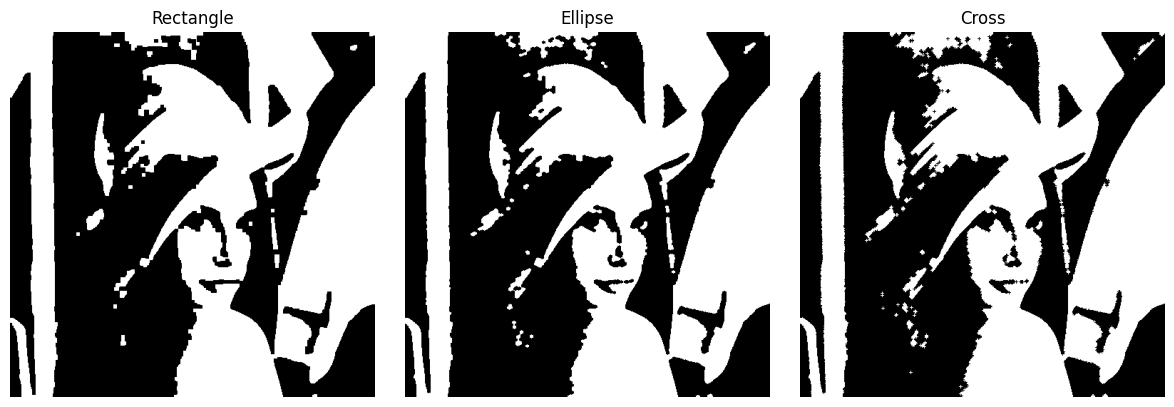

In [8]:
"""
Compare different structuring element shapes.
"""

shapes = {
    "Rectangle": cv2.MORPH_RECT,
    "Ellipse": cv2.MORPH_ELLIPSE,
    "Cross": cv2.MORPH_CROSS
}

plt.figure(figsize=(12, 4))

for i, (name, shape) in enumerate(shapes.items()):
    kernel = cv2.getStructuringElement(shape, (5, 5))
    opened = cv2.morphologyEx(binary_noisy, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    plt.subplot(1, 3, i + 1)
    plt.title(name)
    plt.imshow(cleaned, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Discussion

Elliptical structuring elements provide smoother results, while cross-shaped
kernels preserve thin linear structures more effectively.
This demonstrates the importance of kernel shape in topology preservation.


## Part 4: Order of Morphological Operations

Morphological operations are non-commutative, meaning that changing
the order of opening and closing affects the result.


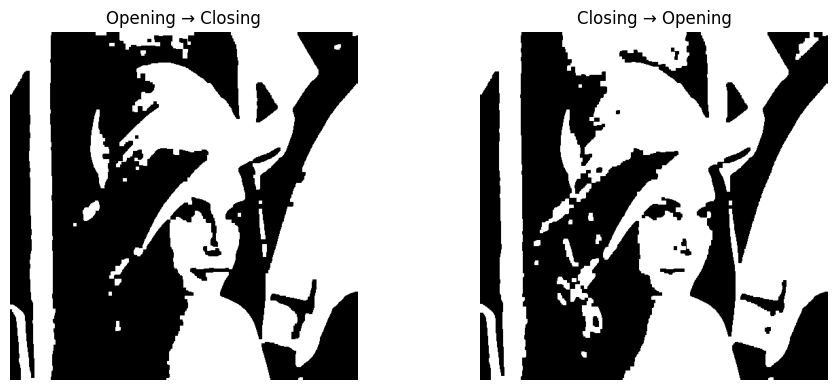

In [9]:
"""
Compare different orders of morphological operations.
"""

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

open_then_close = cv2.morphologyEx(
    cv2.morphologyEx(binary_noisy, cv2.MORPH_OPEN, kernel),
    cv2.MORPH_CLOSE,
    kernel
)

close_then_open = cv2.morphologyEx(
    cv2.morphologyEx(binary_noisy, cv2.MORPH_CLOSE, kernel),
    cv2.MORPH_OPEN,
    kernel
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.title("Opening → Closing"); plt.imshow(open_then_close, cmap="gray"); plt.axis("off")
plt.subplot(1, 2, 2); plt.title("Closing → Opening"); plt.imshow(close_then_open, cmap="gray"); plt.axis("off")
plt.tight_layout()
plt.show()


### Discussion

Applying opening before closing effectively removes noise while
preserving object integrity. Reversing the order may introduce
undesired artifacts or alter object shapes.


## Part 5: Quantitative Evaluation Using Connected Components

To quantitatively assess cleaning effectiveness, the number of
connected components before and after cleaning is measured.


In [10]:
"""
Quantitative evaluation using connected component analysis.
"""

num_labels_before, _ = cv2.connectedComponents(binary_noisy)
num_labels_after, _ = cv2.connectedComponents(cleaned_image)

print(f"Connected Components (Before Cleaning): {num_labels_before}")
print(f"Connected Components (After Cleaning) : {num_labels_after}")


Connected Components (Before Cleaning): 567
Connected Components (After Cleaning) : 62


### Final Discussion

The significant reduction in connected components confirms effective
noise suppression. Morphological operations, when properly configured,
preserve meaningful structures while eliminating small artifacts.

This quantitative analysis supports the qualitative observations.


## Conclusion

This notebook implemented binary image cleaning using morphological
operations, starting from a baseline solution that strictly followed
the exercise instructions.

Extended analysis demonstrated the influence of structuring element
size, shape, operation order, and quantitative evaluation. Together,
these experiments highlight the structural nature of morphological
processing and its effectiveness in binary image analysis.
